In [45]:
import os, time
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

%matplotlib inline
for d in ["plots", "models"]: os.makedirs(d, exist_ok=True)
print("Setup complete.")


Setup complete.


In [46]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]
tracks_path = "../datasets/tracks.csv"


In [47]:
tracks = pd.read_csv(tracks_path)
tracks = tracks.dropna(subset=["name"])
tracks = tracks.sort_values("popularity", ascending=False)
tracks = tracks.drop_duplicates(subset=["name", "id_artists"], keep="first")
tracks = tracks[
    (tracks["duration_ms"] > 0) & (tracks["tempo"] > 0) &
    (tracks["time_signature"] > 0) & (tracks["popularity"] > 0)
]
tracks["release_date"] = pd.to_datetime(tracks["release_date"], format="mixed")
tracks["year"] = tracks["release_date"].dt.year
tracks = tracks[tracks["year"] >= 1950]

dataframe1 = tracks[
    (tracks["release_date"] >= "2010-01-01") &
    (tracks["release_date"] <= "2020-12-31")
].copy()
print(f"2010-2020 rows: {len(dataframe1):,}")


2010-2020 rows: 102,507


In [48]:
# getting our one hot encoder
dataframe1["key"] = dataframe1["key"].astype(int)
key_dummies  = pd.get_dummies(dataframe1["key"],  prefix="key",  dtype=int)
mode_dummies = pd.get_dummies(dataframe1["mode"], prefix="mode", dtype=int)

#keeping numeric colmns
numeric_columns = audio_features + ["explicit", "time_signature", "duration_ms"]
features = pd.concat([dataframe1[numeric_columns], key_dummies, mode_dummies], axis=1)
feature_names = list(features.columns)

HIT_THRESHOLD = 50 # this is just the baseline
binary_target = (dataframe1["popularity"] > HIT_THRESHOLD).astype(int).values

#binary classification
n_hit, n_not = binary_target.sum(), (binary_target == 0).sum()
print(f"Hit:  {n_hit:,}  ({n_hit/len(binary_target):.1%})")
print(f"Not Hit:    {n_not:,}  ({n_not/len(binary_target):.1%})")


Hit:  35,474  (34.6%)
Not Hit:    67,033  (65.4%)


In [49]:
# our validation set will be 2020 data
mask_2020 = (dataframe1["year"] == 2020)

# holdout is the validation we are using
X_holdout = features[mask_2020].values
y_holdout= binary_target[mask_2020]

#X train test, y train test
X_traintest= features[~mask_2020].values
y_tt = binary_target[~mask_2020]

# scale the data
scaler= StandardScaler()
X_tt_scaled  = scaler.fit_transform(X_traintest)
X_val_scaled = scaler.transform(X_holdout)

# 80-20 train test for 2010-2019 data
X_train, X_test, y_train, y_test = train_test_split(
    X_tt_scaled, y_tt, test_size=0.2, random_state=42, stratify=y_tt,
)
print(f"Train: {len(X_train):,} |  Test: {len(X_test):,} |  Holdout: {len(X_val_scaled):,}")


Train: 72,328 |  Test: 18,083 |  Holdout: 12,096


In [50]:
mask_2020

92811      True
92810      True
92813      True
92814      True
92819      True
          ...  
481451    False
416009    False
218212    False
535739    False
218255    False
Name: year, Length: 102507, dtype: bool

## Exploratory Plots

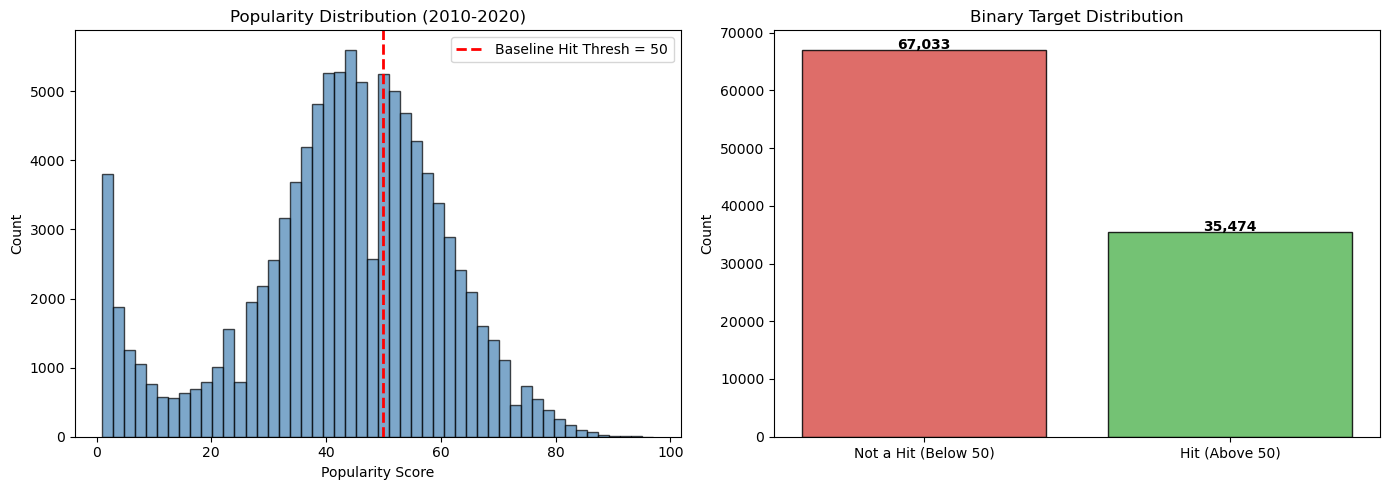

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dataframe1["popularity"], bins=50, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(HIT_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Baseline Hit Thresh = {HIT_THRESHOLD}")
axes[0].set_xlabel("Popularity Score"); axes[0].set_ylabel("Count")
axes[0].set_title("Popularity Distribution (2010-2020)"); axes[0].legend()
axes[1].bar(["Not a Hit (Below 50)", "Hit (Above 50)"], [n_not, n_hit],
            color=["#d9534f","#5cb85c"], edgecolor="black", alpha=0.85)
axes[1].set_ylabel("Count"); axes[1].set_title("Binary Target Distribution")
for i, v in enumerate([n_not, n_hit]):
    axes[1].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout(); plt.savefig("plots/binary_target_distribution.png", dpi=150); plt.show()


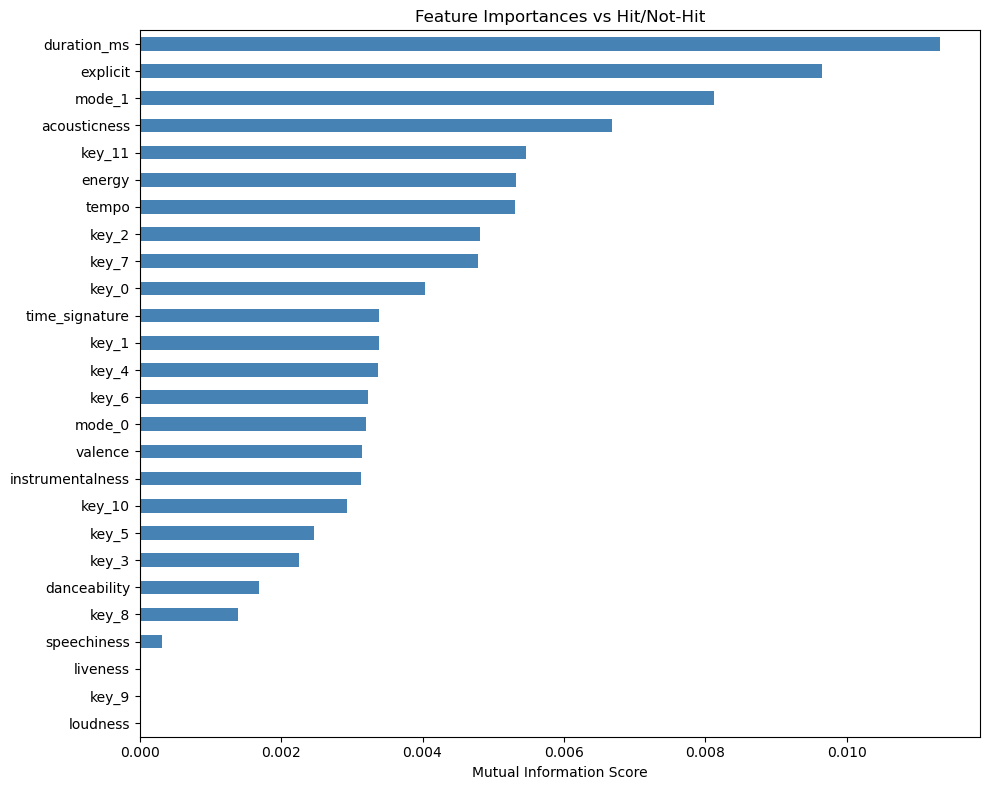

In [52]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
mi_series.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Feature Importances vs Hit/Not-Hit")
plt.tight_layout(); plt.savefig("plots/feature_importance_binary.png", dpi=150); plt.show()


## Model Comparison

In [53]:
# models to use
# storing in dictionary to access in the for loop
candidate_models = {
    "Logistic Regression":LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Naive Bayes":GaussianNB(),
    "KNN (k=15)":KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Random Forest":RandomForestClassifier(n_estimators=400, max_depth=25, class_weight="balanced", random_state=42, n_jobs=-1),
    "Extra Trees":ExtraTreesClassifier(n_estimators=300, max_depth=20,  class_weight="balanced", random_state=42, n_jobs=-1),
    "HistGradientBoosting":  HistGradientBoostingClassifier(max_iter=400, max_depth=10, learning_rate=0.05, min_samples_leaf=20, class_weight="balanced", random_state=42),
}

In [54]:
comparison_rows = []

for name, m in candidate_models.items():
    t0 = time.time()
    m.fit(X_train, y_train)
    elapsed = time.time() - t0

    p_te  = m.predict_proba(X_test)[:, 1]
    p_val = m.predict_proba(X_val_scaled)[:, 1]

    # Use default 0.5 threshold for quick comparison
    yp_te  = (p_te  >= 0.5).astype(int)
    yp_val = (p_val >= 0.5).astype(int)

    row = {
        "Model":name,
        "Fit": round(elapsed, 1),
        "Test AUC": round(roc_auc_score(y_test,    p_te),  4),
        "Val AUC":round(roc_auc_score(y_holdout, p_val), 4),
        "Test Acc":round(accuracy_score(y_test,    yp_te),  3),
        "Val Acc": round(accuracy_score(y_holdout, yp_val), 3),
        "Test F1 Mac":round(f1_score(y_test,    yp_te,  average="macro", zero_division=0), 3),
        "Val F1 Mac":round(f1_score(y_holdout, yp_val, average="macro", zero_division=0), 3),
        "Test F1 Hit": round(f1_score(y_test,    yp_te,  pos_label=1, zero_division=0), 3),
        "Val F1 Hit":round(f1_score(y_holdout, yp_val, pos_label=1, zero_division=0), 3),
        "_proba_te": p_te,
        "_proba_val": p_val,
        "_model":m,
    }
    comparison_rows.append(row)
    print(f"{name:<25}  fit={elapsed:5.1f}s  test_auc={row['Test AUC']:.4f}  val_auc={row['Val AUC']:.4f}")

Logistic Regression        fit=  0.0s  test_auc=0.6231  val_auc=0.6848
Naive Bayes                fit=  0.0s  test_auc=0.6039  val_auc=0.6850
KNN (k=15)                 fit=  0.0s  test_auc=0.6118  val_auc=0.6421
Random Forest              fit=  5.9s  test_auc=0.6770  val_auc=0.7150
Extra Trees                fit=  1.5s  test_auc=0.6548  val_auc=0.7067
HistGradientBoosting       fit=  0.9s  test_auc=0.6778  val_auc=0.7173


In [55]:
comp_df = pd.DataFrame(comparison_rows).drop(columns=["_proba_te","_proba_val","_model"])

In [56]:
comp_df

,Model,Fit,Test AUC,Val AUC,Test Acc,Val Acc,Test F1 Mac,Val F1 Mac,Test F1 Hit,Val F1 Hit
0,Logistic Regression,0.0,0.6231,0.6848,0.593,0.642,0.569,0.636,0.465,0.684
1,Naive Bayes,0.0,0.6039,0.6850,0.625,0.597,0.569,0.597,0.414,0.590
2,KNN (k=15),0.0,0.6118,0.6421,0.679,0.517,0.542,0.490,0.291,0.372
3,Random Forest,5.9,0.6770,0.7150,0.698,0.563,0.572,0.549,0.340,0.468
4,Extra Trees,1.5,0.6548,0.7067,0.658,0.621,0.600,0.621,0.448,0.623
5,HistGradientBoosting,0.9,0.6778,0.7173,0.623,0.669,0.603,0.658,0.515,0.720


/var/folders/40/6qdtls9s3b7727m4pn27vv9c0000gn/T/ipykernel_71204/2879603323.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(comparison_rows))


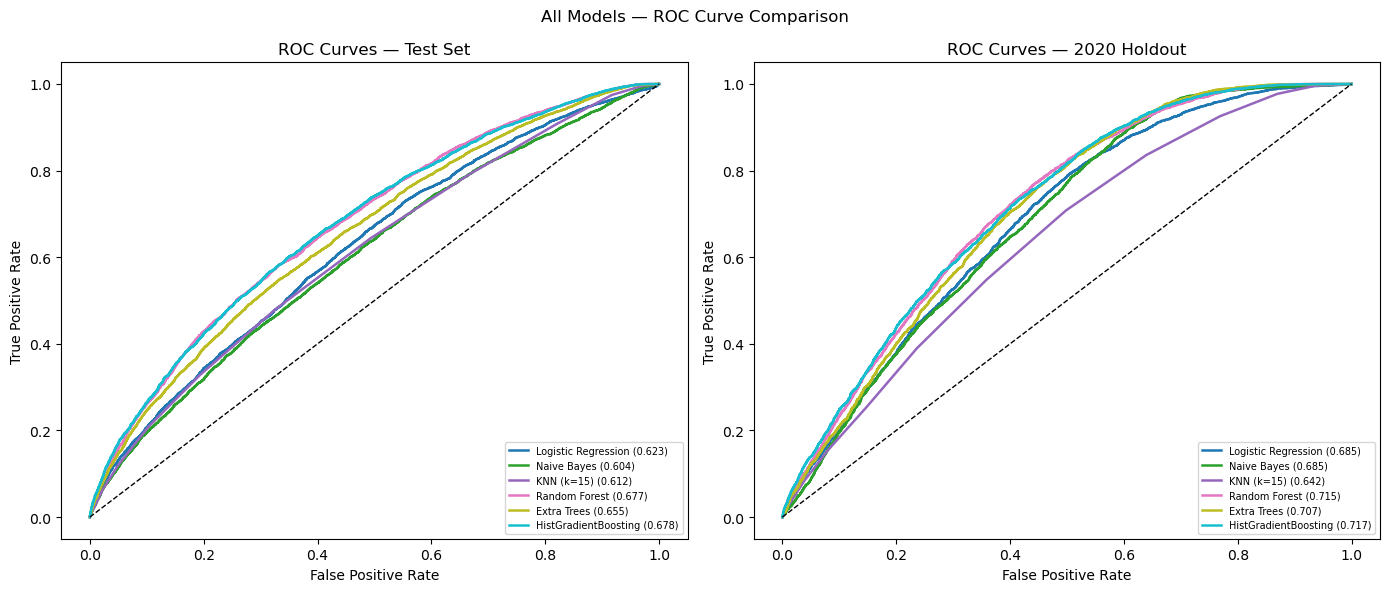

In [57]:
# ROC curves for each 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.get_cmap("tab10", len(comparison_rows))

for i, row in enumerate(comparison_rows):
    color = cmap(i)
    for ax, y_true, proba, split in [
        (axes[0], y_test,    row["_proba_te"],  "Test Set"),
        (axes[1], y_holdout, row["_proba_val"], "2020 Holdout"),
    ]:
        fpr, tpr, _ = roc_curve(y_true, proba)
        auc = roc_auc_score(y_true, proba)
        ax.plot(fpr, tpr, color=color, lw=1.8, label=f"{row['Model']} ({auc:.3f})")

for ax, title in zip(axes, ["Test Set", "2020 Holdout"]):
    ax.plot([0,1],[0,1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC Curves — {title}")
    ax.legend(fontsize=7, loc="lower right")

plt.suptitle("All Models — ROC Curve Comparison", fontsize=12)
plt.tight_layout()
plt.savefig("plots/model_comparison_roc.png", dpi=150)
plt.show()


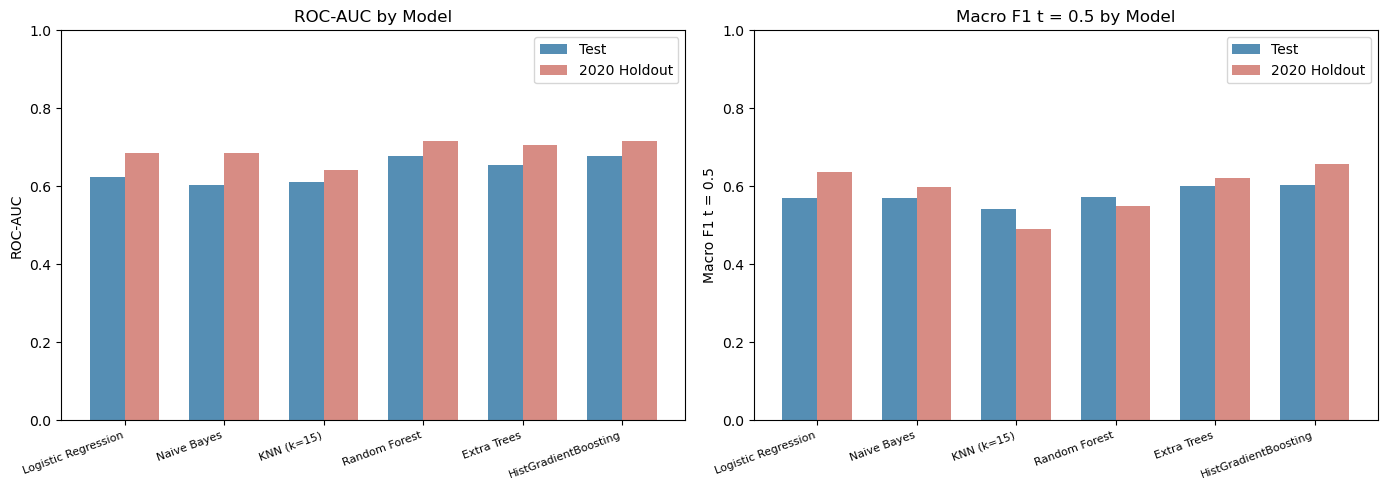

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
models_list = [r["Model"] for r in comparison_rows]
x = np.arange(len(models_list))
width = 0.35

for ax, (test_metric, val_metric, title) in zip(axes, [
    ("Test AUC",    "Val AUC",    "ROC-AUC"),
    ("Test F1 Mac", "Val F1 Mac", "Macro F1 t = 0.5"),
]):
    test_vals = [r[test_metric] for r in comparison_rows]
    val_vals = [r[val_metric] for r in comparison_rows]
    ax.bar(x - width/2, test_vals, width, label="Test",         color="#377aa7", alpha=0.85)
    ax.bar(x + width/2, val_vals,  width, label="2020 Holdout", color="#d0786f", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models_list, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(title)
    ax.set_title(f"{title} by Model")
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("plots/model_comparison_bars.png", dpi=150)
plt.show()


## Best Model — Threshold Tuning

In [59]:
# Automatically select the model with the highest Val AUC
best_idx   = max(range(len(comparison_rows)), key=lambda i: comparison_rows[i]["Val AUC"])
best_name  = comparison_rows[best_idx]["Model"]
model      = comparison_rows[best_idx]["_model"]
proba_te   = comparison_rows[best_idx]["_proba_te"]
proba_val  = comparison_rows[best_idx]["_proba_val"]

print(f"Best model by 2020 holdout AUC: {best_name}")
print(f"  Test  AUC: {roc_auc_score(y_test,    proba_te):.4f}")
print(f"  Val   AUC: {roc_auc_score(y_holdout, proba_val):.4f}")


Best model by 2020 holdout AUC: HistGradientBoosting
  Test  AUC: 0.6778
  Val   AUC: 0.7173


## Threshold Selection

Balanced F1 (max macro F1):       t = 0.55
High Recall (Hit recall >= 0.90): t = 0.10
High Precision (Hit precision  >= 0.75):  t = 0.79


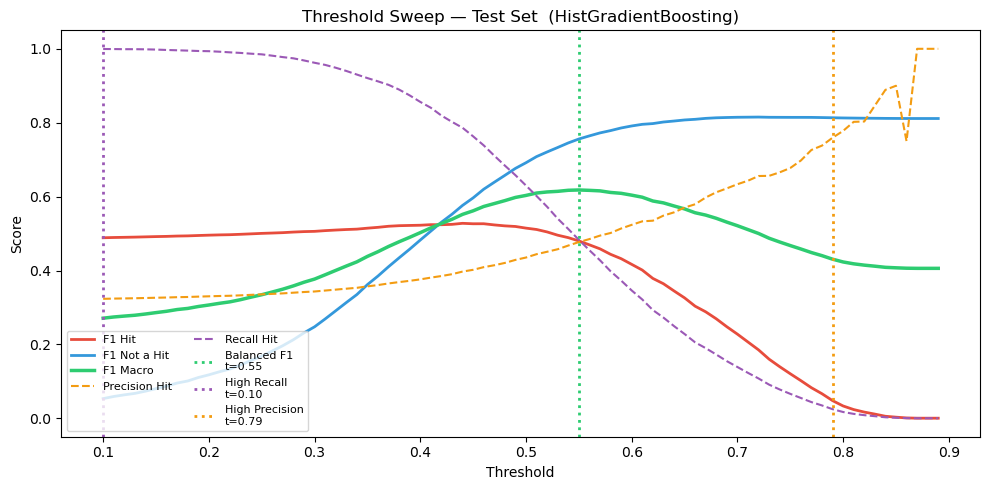

In [60]:
thresholds = np.arange(0.10, 0.90, 0.01)
rows = []
for t in thresholds:
    yp = (proba_te >= t).astype(int)
    rows.append({
        "threshold": t,
        "f1_macro": f1_score(y_test, yp, average="macro",   zero_division=0),
        "f1_hit": f1_score(y_test, yp, pos_label=1,       zero_division=0),
        "f1_not_hit": f1_score(y_test, yp, pos_label=0,       zero_division=0),
        "precision_hit": precision_score(y_test, yp, pos_label=1, zero_division=0),
        "recall_hit":recall_score(y_test,    yp, pos_label=1, zero_division=0),
        "accuracy": accuracy_score(y_test, yp),
    })

sweep = pd.DataFrame(rows)

t_balanced  = sweep.loc[sweep["f1_macro"].idxmax(), "threshold"]
hr_rows     = sweep[sweep["recall_hit"] >= 0.90]
t_recall    = float(hr_rows["threshold"].min()) if len(hr_rows) else float(sweep["threshold"].iloc[0])
hp_rows     = sweep[sweep["precision_hit"] >= 0.75]
t_high_prec = float(hp_rows["threshold"].min()) if len(hp_rows) else float(sweep["threshold"].iloc[-1])

print(f"Balanced F1 (max macro F1):       t = {t_balanced:.2f}")
print(f"High Recall (Hit recall >= 0.90): t = {t_recall:.2f}")
print(f"High Precision (Hit precision  >= 0.75):  t = {t_high_prec:.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["threshold"], sweep["f1_hit"],        label="F1 Hit",        color="#e74c3c", lw=2)
ax.plot(sweep["threshold"], sweep["f1_not_hit"],    label="F1 Not a Hit",  color="#3498db", lw=2)
ax.plot(sweep["threshold"], sweep["f1_macro"],      label="F1 Macro",      color="#2ecc71", lw=2.5)
ax.plot(sweep["threshold"], sweep["precision_hit"], label="Precision Hit", color="#f39c12", lw=1.5, linestyle="--")
ax.plot(sweep["threshold"], sweep["recall_hit"],    label="Recall Hit",    color="#9b59b6", lw=1.5, linestyle="--")
for t, label, color in [
    (t_balanced,  f"Balanced F1\nt={t_balanced:.2f}",    "#2ecc71"),
    (t_recall,    f"High Recall\nt={t_recall:.2f}",      "#9b59b6"),
    (t_high_prec, f"High Precision\nt={t_high_prec:.2f}","#f39c12"),
]:
    ax.axvline(t, color=color, linestyle=":", linewidth=2, label=label)
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title(f"Threshold Sweep — Test Set  ({best_name})")
ax.legend(loc="lower left", fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig("plots/threshold_sweep.png", dpi=150); plt.show()


## Operating Points on ROC Curve

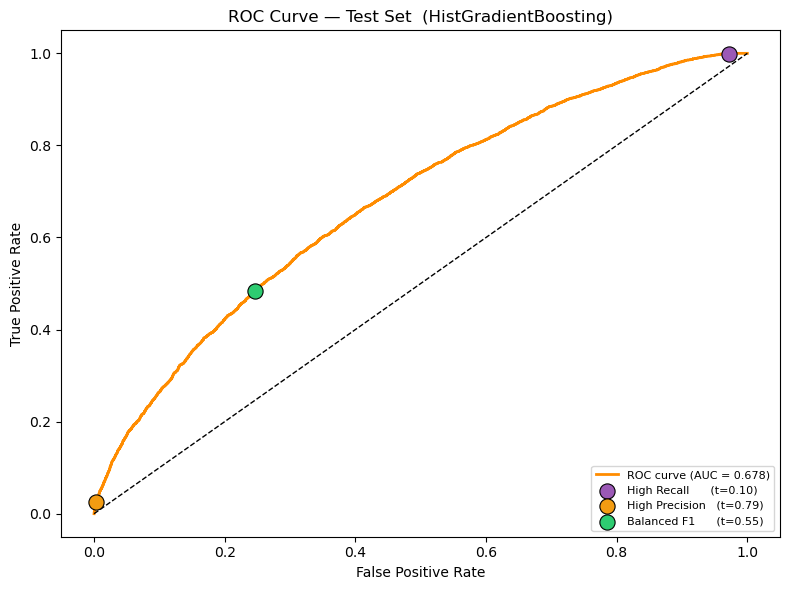

In [61]:
operating_points = {
    f"High Recall      (t={t_recall:.2f})":    t_recall,
    f"High Precision   (t={t_high_prec:.2f})": t_high_prec,
    f"Balanced F1      (t={t_balanced:.2f})":  t_balanced,
}
op_colors  = ["#9b59b6", "#f39c12", "#2ecc71"]
summary_rows = []

fig, ax = plt.subplots(figsize=(8, 6))
fpr_base, tpr_base, _ = roc_curve(y_test, proba_te)
auc = roc_auc_score(y_test, proba_te)
ax.plot(fpr_base, tpr_base, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1)
for (op_name, t), color in zip(operating_points.items(), op_colors):
    yp = (proba_te >= t).astype(int)
    ax.scatter((yp[y_test==0]==1).mean(), (yp[y_test==1]==1).mean(),
               s=120, color=color, zorder=5, edgecolors="black", linewidths=0.8, label=op_name)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — Test Set  ({best_name})")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig("plots/operating_point_roc.png", dpi=150); plt.show()

for op_name, t in operating_points.items():
    yp_val = (proba_val >= t).astype(int)
    summary_rows.append({
        "Operating Point": op_name,
        "Threshold":  round(t, 2),
        "Accuracy":   round(accuracy_score(y_holdout, yp_val), 3),
        "Prec Hit":   round(precision_score(y_holdout, yp_val, pos_label=1, zero_division=0), 3),
        "Rec  Hit":   round(recall_score(y_holdout,   yp_val, pos_label=1, zero_division=0), 3),
        "F1   Hit":   round(f1_score(y_holdout,       yp_val, pos_label=1, zero_division=0), 3),
        "F1 Macro":   round(f1_score(y_holdout,       yp_val, average="macro", zero_division=0), 3),
        "ROC-AUC":    round(roc_auc_score(y_holdout, proba_val), 3),
    })


### ROC and Metrics for Validation Set

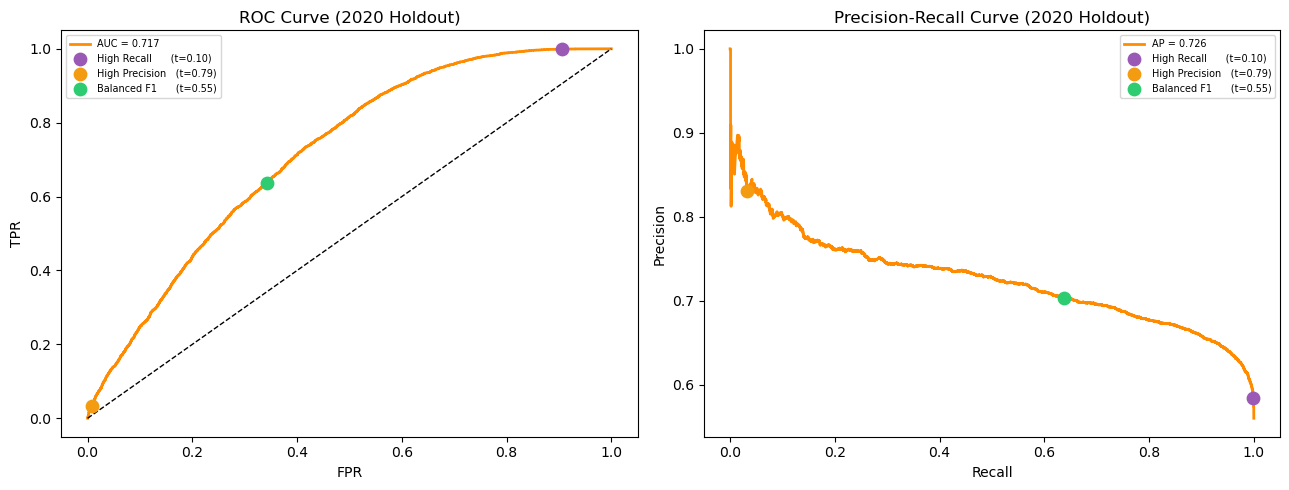

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_holdout, proba_val)
auc = roc_auc_score(y_holdout, proba_val)
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0,1],[0,1], "k--", lw=1)
for (op_name, t), color in zip(operating_points.items(), op_colors):
    yp = (proba_val >= t).astype(int)
    axes[0].scatter((yp[y_holdout==0]==1).mean(), (yp[y_holdout==1]==1).mean(),
                    s=80, color=color, zorder=5, label=op_name)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve (2020 Holdout)"); axes[0].legend(fontsize=7)

prec_c, rec_c, _ = precision_recall_curve(y_holdout, proba_val)
ap = average_precision_score(y_holdout, proba_val)
axes[1].plot(rec_c, prec_c, color="darkorange", lw=2, label=f"AP = {ap:.3f}")
for (op_name, t), color in zip(operating_points.items(), op_colors):
    yp = (proba_val >= t).astype(int)
    axes[1].scatter(recall_score(y_holdout, yp, pos_label=1, zero_division=0),
                    precision_score(y_holdout, yp, pos_label=1, zero_division=0),
                    s=80, color=color, zorder=5, label=op_name)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (2020 Holdout)"); axes[1].legend(fontsize=7)

plt.tight_layout(); plt.savefig("plots/roc_pr_curves.png", dpi=150); plt.show()


In [63]:
TARGET_NAMES    = ["Not a Hit", "Hit"]
chosen_threshold = t_balanced

y_pred_val = (proba_val >= chosen_threshold).astype(int)

print(f"2020 Holdout Results — {best_name} (threshold = {chosen_threshold:.2f})\n")
print(f"Accuracy : {accuracy_score(y_holdout, y_pred_val):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_holdout, proba_val):.4f}")
print()
print(classification_report(y_holdout, y_pred_val, target_names=TARGET_NAMES))


2020 Holdout Results — HistGradientBoosting (threshold = 0.55)

Accuracy : 0.6459
ROC-AUC  : 0.7173

              precision    recall  f1-score   support

   Not a Hit       0.59      0.66      0.62      5321
         Hit       0.70      0.64      0.67      6775

    accuracy                           0.65     12096
   macro avg       0.65      0.65      0.64     12096
weighted avg       0.65      0.65      0.65     12096



In [64]:
summary_df = pd.DataFrame(summary_rows)

summary_df

,Operating Point,Threshold,Accuracy,Prec Hit,Rec Hit,F1 Hit,F1 Macro,ROC-AUC
0,High Recall (t=0.10),0.10,0.601,0.584,0.999,0.737,0.455,0.717
1,High Precision (t=0.79),0.79,0.454,0.831,0.033,0.063,0.339,0.717
2,Balanced F1 (t=0.55),0.55,0.646,0.703,0.637,0.668,0.644,0.717


## Calibration Check

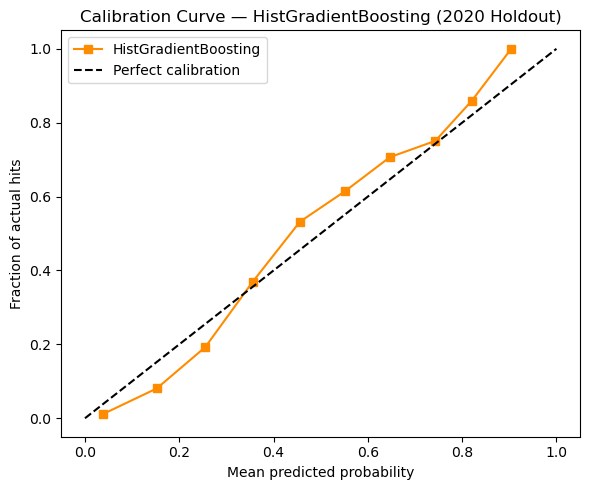

In [65]:
fig, ax = plt.subplots(figsize=(6, 5))
frac_pos, mean_pred = calibration_curve(y_holdout, proba_val, n_bins=10)
ax.plot(mean_pred, frac_pos, "s-", label=best_name, color="darkorange")
ax.plot([0,1],[0,1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of actual hits")
ax.set_title(f"Calibration Curve — {best_name} (2020 Holdout)")
ax.legend()
plt.tight_layout(); plt.savefig("plots/calibration_curve.png", dpi=150); plt.show()


In [66]:
joblib.dump(model,  "models/hit_detector.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump({
    "model_name":      best_name,
    "hit_threshold":   HIT_THRESHOLD,
    "feature_names":   feature_names,
    "task":            "binary_hit_detection",
    "t_high_recall":   float(t_recall),
    "t_high_precision":float(t_high_prec),
    "t_balanced_f1":   float(t_balanced),
}, "models/meta.pkl")

print(f"Saved best model: {best_name}")
print(f"  High Recall    (rec  >= 0.90): {t_recall:.2f}")
print(f"  High Precision (prec >= 0.75): {t_high_prec:.2f}")
print(f"  Balanced F1    (max macro F1): {t_balanced:.2f}")


Saved best model: HistGradientBoosting
  High Recall    (rec  >= 0.90): 0.10
  High Precision (prec >= 0.75): 0.79
  Balanced F1    (max macro F1): 0.55
